# 1. Análise Exploratória

In [302]:
# 1. Análise Exploratória
import seaborn as sb
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.neighbors import LocalOutlierFactor
from mlxtend.frequent_patterns import apriori, association_rules
from sklearn.metrics import r2_score, mean_absolute_error, accuracy_score, confusion_matrix, ConfusionMatrixDisplay


# Não limitar o tamanho da resposta
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

In [303]:
train_csv = pd.read_csv("data/train.csv")

## 1.1 Distribuição das Variáveis

### 1.1.1 Características das Variáveis
Ao analisar o dataframe gerado abaixo, vemos que os dados são bem diferentes, com vários dados cotendo nulls, outliers e categorias diferentes.

In [304]:
def get_outlier(series: pd.Series) -> pd.Series:
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3-q1
    lim_sup = q3+(iqr*1.5)
    lim_inf = q1-(iqr*1.5)
    return series[(series < lim_inf) | (series > lim_sup)]

def set_outliers(series: pd.Series):
    if not pd.api.types.is_numeric_dtype(series.dtype):
        return "Não elegível"
    if get_outlier(series).any():
        return "Sim"
    return "Não"

exploracao_csv = pd.DataFrame(
    {
        "categoria": train_csv.dtypes.map(lambda x: "Numérico" if x.kind in "iufc" else "Categórico"),
        "tem_null": train_csv.isna().sum().map(lambda x: "Sim" if x >= 1 else "Não"),
        "tem_outliers": train_csv.apply(set_outliers)
    }
)

exploracao_csv.sort_values(by=["categoria", "tem_null", "tem_outliers"])

,categoria,tem_null,tem_outliers
MSZoning,Categórico,Não,Não elegível
Street,Categórico,Não,Não elegível
LotShape,Categórico,Não,Não elegível
LandContour,Categórico,Não,Não elegível
Utilities,Categórico,Não,Não elegível
LotConfig,Categórico,Não,Não elegível
LandSlope,Categórico,Não,Não elegível
Neighborhood,Categórico,Não,Não elegível
Condition1,Categórico,Não,Não elegível
Condition2,Categórico,Não,Não elegível


### 1.1.2 Distribuição do Preço de Venda das Propriedades
Observando o histograma com a linha de densidade (KDE), podemos destacar os seguintes pontos importantes:
1. **Assimetria Positiva:** A distribuição dos preços não é uma curva normal perfeita (simétrica). Ela possui uma assimetria à direita, formando uma "cauda longa" que se estende para os valores mais altos.
2. **Concentração de Valores:** A grande maioria dos imóveis é vendida por um preço entre **\$100.000 e \$200.000**. O pico principal do gráfico ocorre próximo aos \$150.000.
3. **Presença de Outliers:** A cauda longa à direita deixa claro que existem propriedades com preços de venda muito acima da maioria, chegando a valores que ultrapassam a marca de **\$700.000**. Embora sejam poucos imóveis (frequência baixa), eles impactam as métricas globais, puxando a média de preços para cima.

Isso implica que utilizar uma transformação matemática como a transformação logarítmica trará muitos benefícios nas etapas de machine learning.

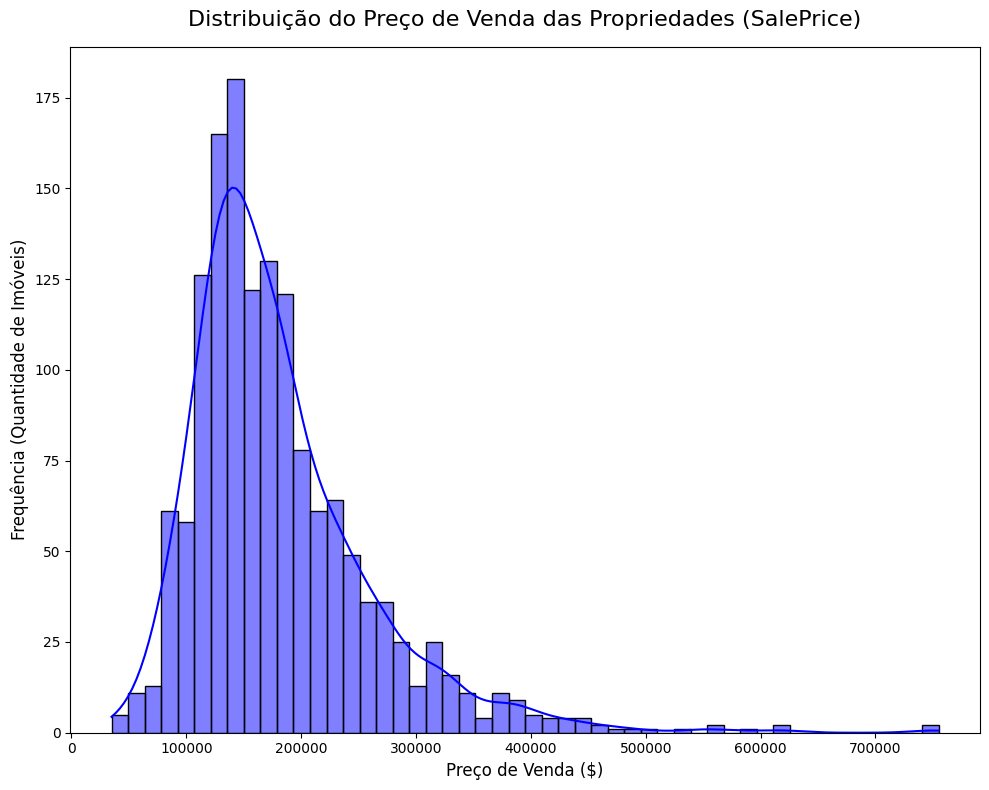

In [305]:
plt.figure(figsize=(10,8))
sb.histplot(
    train_csv["SalePrice"], kde=True, bins=50, color="blue"
)
plt.title("Distribuição do Preço de Venda das Propriedades (SalePrice)", fontsize=16, pad=15)
plt.xlabel("Preço de Venda ($)", fontsize=12)
plt.ylabel("Frequência (Quantidade de Imóveis)", fontsize=12)

plt.tight_layout()
plt.show()


## 1.2 Correlações e Dispersões

### 1.2.1 Gráfico de Correlação Geral
Olhando a matriz gerada abaixo, fica um pouco complicado analisar as correlações devido a grande quantidade de variáveis.

Então nós vamos utilizar outra forma...

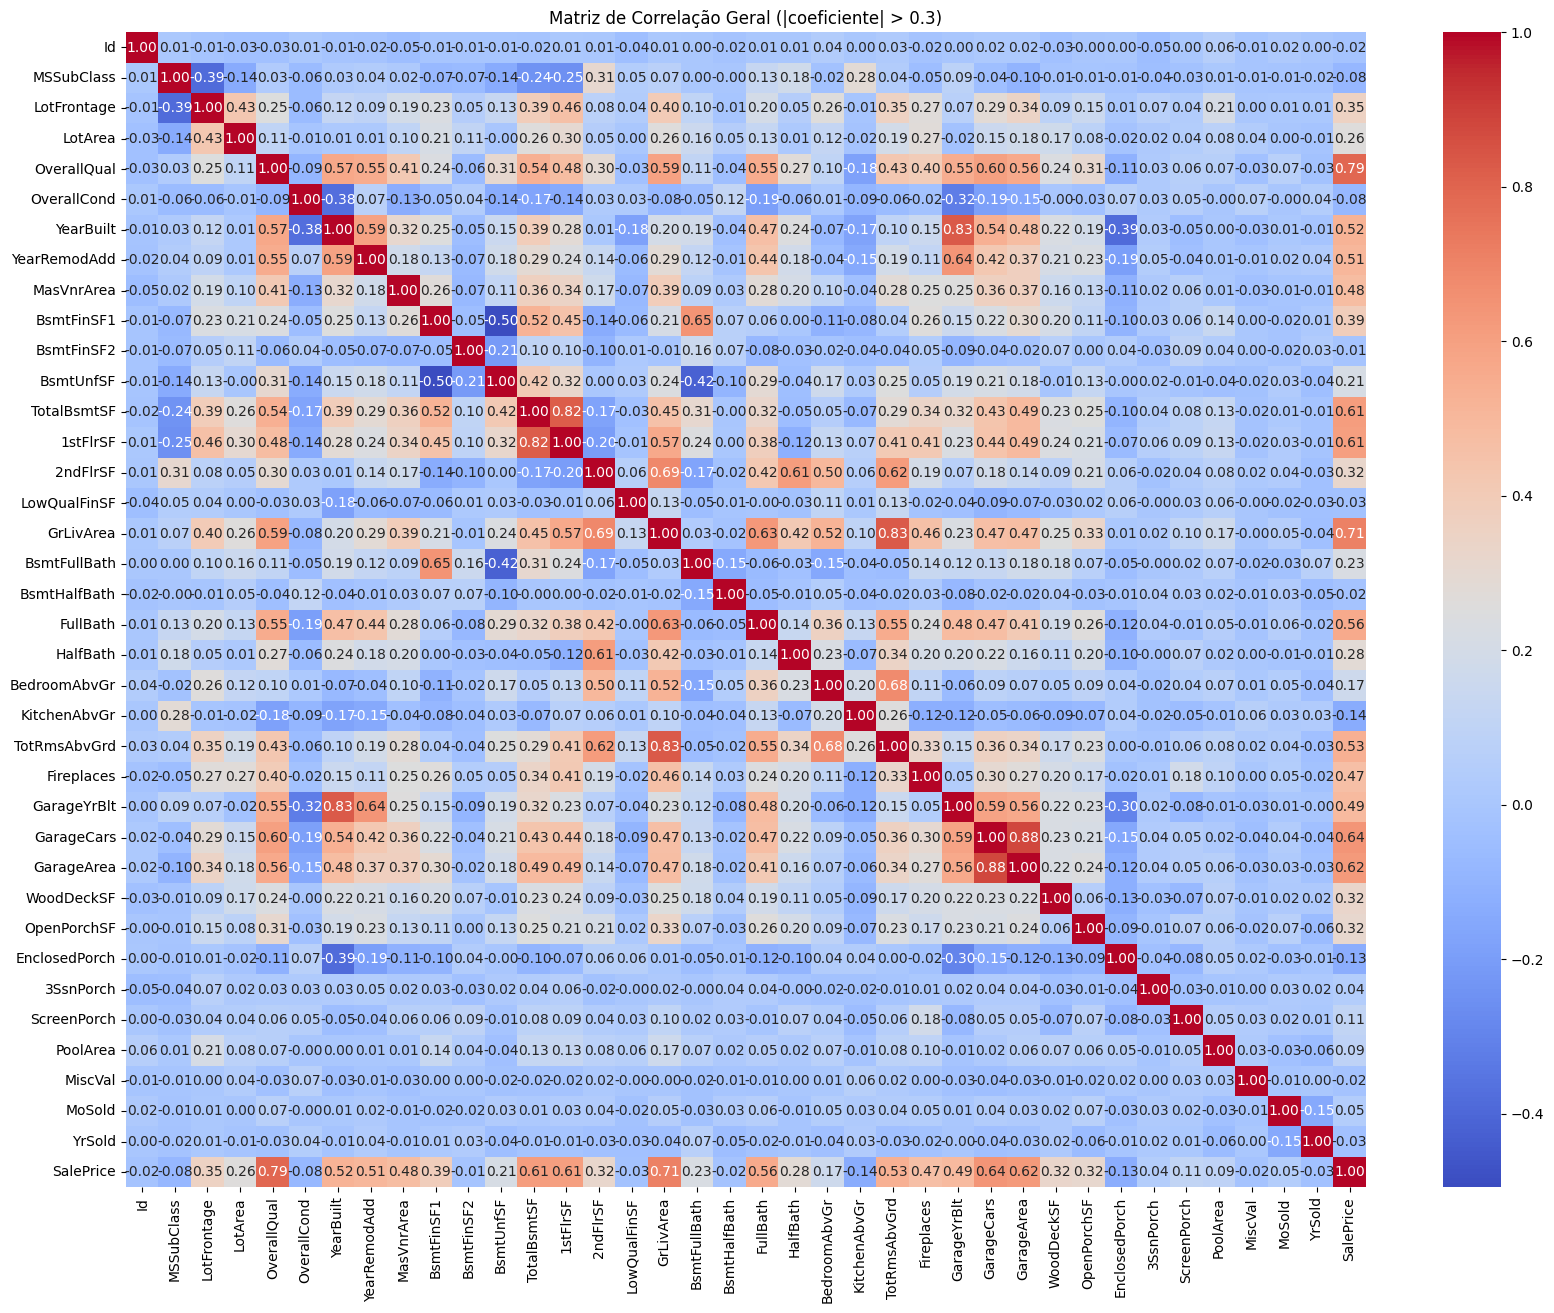

In [306]:
corr_matrix = train_csv.corr(numeric_only=True)

plt.figure(figsize=(20, 15))
sb.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlação Geral (|coeficiente| > 0.3)")
plt.show()

### 1.2.1 Correlações com a variável de preço da propriedade (SalePrice)

Fizemos um filtro nos coeficientes de correlação absolutos das variáveis pegando somente as variáveis com um coeficiente relevante.

Assim a análise fica mais prática.

1. **OverralQual (Qualidade Geral)**
2. **GrLivArea (Área Habitável Acima do Solo)**
3. **GarageCars (Capacidade de Carros na Garagem)**
4. **GarageArea (Área da Garagem)**
5. **TotalBsmtSF (Área Total do Porão)**

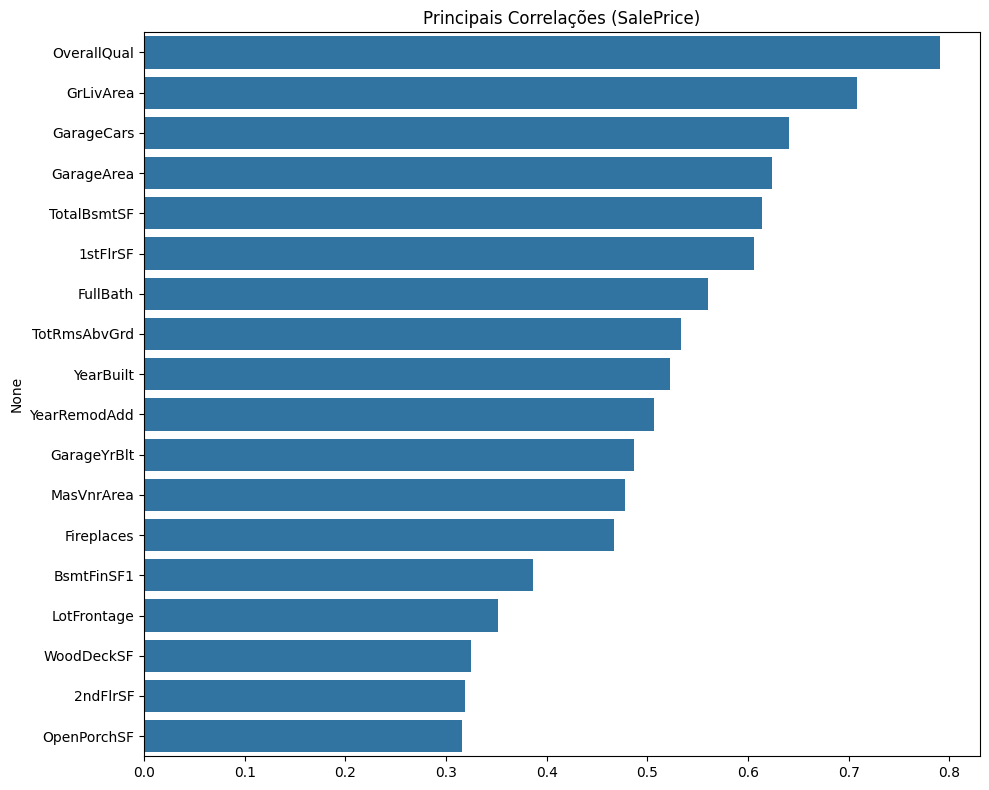

In [307]:
corr = train_csv.corr(numeric_only=True)["SalePrice"].sort_values(ascending=False).drop("SalePrice")

corr = corr.to_frame(name="correlation")
corr["abs_correlation"] = corr["correlation"].abs()

# Pega todas as variáveis com correlação absoluta maior ou igual que 0.3
best_corr = corr[corr["abs_correlation"] >= 0.3].sort_values(by="abs_correlation", ascending=False)

plt.figure(figsize=(10, 8))
sb.barplot(
    x=best_corr["correlation"].values,
    y=best_corr.index,
)
plt.title("Principais Correlações (SalePrice)")
plt.tight_layout()
plt.show()



### 1.2.2 Dispersão entre a área da propriedade e o preço (GrLivArea x SalePrice)
Aplicando um scatter plot na área habitável, vemos que quanto maior a área, maior o preço de venda.

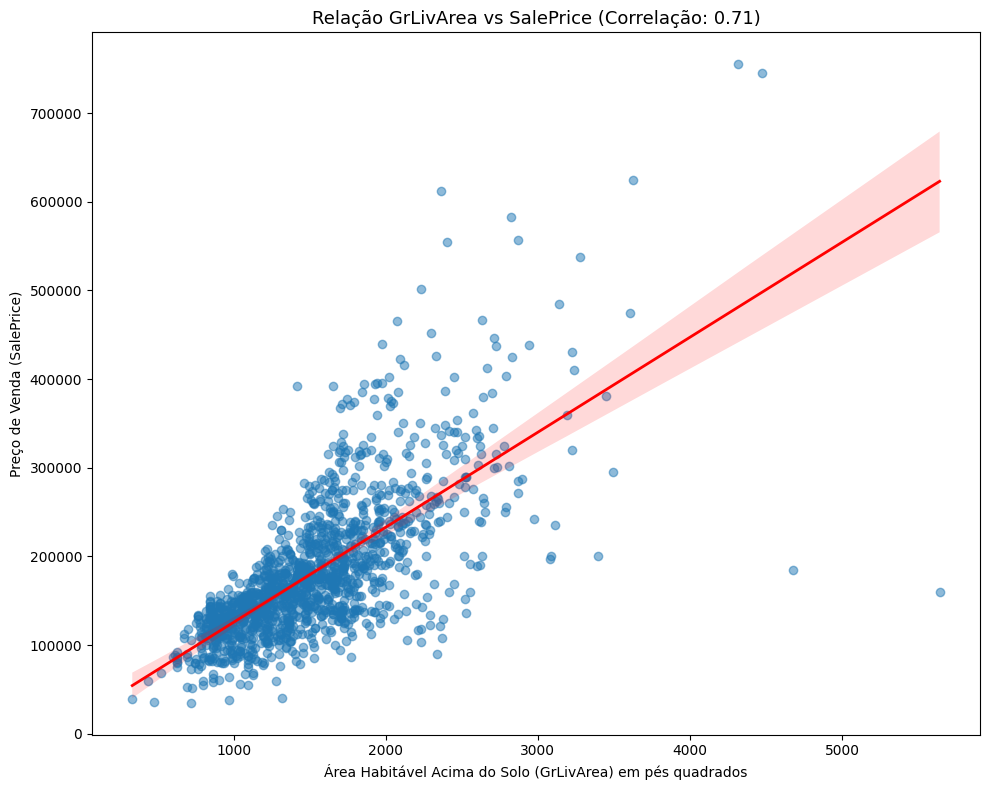

In [308]:
corr: pd.DataFrame = train_csv["GrLivArea"].corr(train_csv["SalePrice"])

plt.figure(figsize=(10,8))
sb.regplot(
    data=train_csv,
    x="GrLivArea",
    y="SalePrice",
    scatter_kws={"alpha":0.5, "color": "#1f77b4"},
    line_kws={"color": "red", "linewidth": 2}
)

plt.title(f"Relação GrLivArea vs SalePrice (Correlação: {corr:.2f})", fontsize=13)
plt.xlabel("Área Habitável Acima do Solo (GrLivArea) em pés quadrados")
plt.ylabel("Preço de Venda (SalePrice)")
plt.tight_layout()
plt.show()

# 2 Feature Engineering

## 2.1 Renomeação de variáveis

In [309]:
dicionario_nomes = {
    'Id': 'Id',
    'MSSubClass': 'Classe_Imovel',
    'MSZoning': 'Zona_Classificacao',
    'LotFrontage': 'Fachada_Lote_Pes',
    'LotArea': 'Area_Lote_Pes2',
    'Street': 'Tipo_Rua',
    'Alley': 'Tipo_Beco',
    'LotShape': 'Formato_Lote',
    'LandContour': 'Contorno_Terreno',
    'Utilities': 'Utilidades_Disponiveis',
    'LotConfig': 'Configuracao_Lote',
    'LandSlope': 'Inclinacao_Terreno',
    'Neighborhood': 'Bairro',
    'Condition1': 'Proximidade_Condicao1',
    'Condition2': 'Proximidade_Condicao2',
    'BldgType': 'Tipo_Habitacao',
    'HouseStyle': 'Estilo_Habitacao',
    'OverallQual': 'Qualidade_Geral',
    'OverallCond': 'Condicao_Geral',
    'YearBuilt': 'Ano_Construcao',
    'YearRemodAdd': 'Ano_Reforma',
    'RoofStyle': 'Estilo_Telhado',
    'RoofMatl': 'Material_Telhado',
    'Exterior1st': 'Revestimento_Externo1',
    'Exterior2nd': 'Revestimento_Externo2',
    'MasVnrType': 'Tipo_Alvenaria',
    'MasVnrArea': 'Area_Alvenaria',
    'ExterQual': 'Qualidade_Externa',
    'ExterCond': 'Condicao_Externa',
    'Foundation': 'Tipo_Fundacao',
    'BsmtQual': 'Qualidade_Porao',
    'BsmtCond': 'Condicao_Porao',
    'BsmtExposure': 'Exposicao_Porao',
    'BsmtFinType1': 'Acabamento_Porao1',
    'BsmtFinSF1': 'Area_Acab_Porao1',
    'BsmtFinType2': 'Acabamento_Porao2',
    'BsmtFinSF2': 'Area_Acab_Porao2',
    'BsmtUnfSF': 'Area_Porao_Inacabado',
    'TotalBsmtSF': 'Area_Total_Porao',
    'Heating': 'Tipo_Aquecimento',
    'HeatingQC': 'Qualidade_Aquecimento',
    'CentralAir': 'Ar_Condicionado_Central',
    'Electrical': 'Sistema_Eletrico',
    '1stFlrSF': 'Area_Primeiro_Andar',
    '2ndFlrSF': 'Area_Segundo_Andar',
    'LowQualFinSF': 'Area_Baixa_Qualidade',
    'GrLivArea': 'Area_Habitavel_Acima_Solo',
    'BsmtFullBath': 'Banheiros_Completos_Porao',
    'BsmtHalfBath': 'Lavabos_Porao',
    'FullBath': 'Banheiros_Completos',
    'HalfBath': 'Lavabos',
    'BedroomAbvGr': 'Quartos_Acima_Solo',
    'KitchenAbvGr': 'Cozinhas_Acima_Solo',
    'KitchenQual': 'Qualidade_Cozinha',
    'TotRmsAbvGrd': 'Total_Comodos_Acima_Solo',
    'Functional': 'Funcionalidade_Casa',
    'Fireplaces': 'Lareiras',
    'FireplaceQu': 'Qualidade_Lareira',
    'GarageType': 'Tipo_Garagem',
    'GarageYrBlt': 'Ano_Construcao_Garagem',
    'GarageFinish': 'Acabamento_Garagem',
    'GarageCars': 'Capacidade_Carros_Garagem',
    'GarageArea': 'Area_Garagem',
    'GarageQual': 'Qualidade_Garagem',
    'GarageCond': 'Condicao_Garagem',
    'PavedDrive': 'Entrada_Garagem_Pavimentada',
    'WoodDeckSF': 'Area_Deck_Madeira',
    'OpenPorchSF': 'Area_Varanda_Aberta',
    'EnclosedPorch': 'Area_Varanda_Fechada',
    '3SsnPorch': 'Area_Varanda_3Estacoes',
    'ScreenPorch': 'Area_Varanda_Tela',
    'PoolArea': 'Area_Piscina',
    'PoolQC': 'Qualidade_Piscina',
    'Fence': 'Qualidade_Cerca',
    'MiscFeature': 'Caracteristica_Adicional',
    'MiscVal': 'Valor_Caracteristica_Adic',
    'MoSold': 'Mes_Venda',
    'YrSold': 'Ano_Venda',
    'SaleType': 'Tipo_Venda',
    'SaleCondition': 'Condicao_Venda',
    'SalePrice': 'Preco_Venda'
}

train_df = train_csv.rename(columns=dicionario_nomes) 

## 2.2 Codificação das variáveis

Aqui fizemos a codificação das variáveis para facilitar as análises dos algorítmos.
Nós codificamos da seguinte forma:
- **Valores Nulos:** Preenchidos com "Nenhum";
- **Variáveis Categóricas (Com Ordem):** Preenchidos com pesos numéricos (ex: Excelente = 5, Ruim = 1);
- **Variáveis Categóricas (Sem Ordem):** Transformadas em colunas Binárias (One-Hot Encoding)

In [310]:
train_df['Classe_Imovel'] = train_df['Classe_Imovel'].astype(str)

cols_qualidade = [
    'Qualidade_Externa', 'Condicao_Externa', 'Qualidade_Porao', 'Condicao_Porao',
    'Qualidade_Aquecimento', 'Qualidade_Cozinha', 'Qualidade_Lareira', 
    'Qualidade_Garagem', 'Condicao_Garagem', 'Qualidade_Piscina'
]

# Preencher Nulos em colunas que significam "Não possui" ANTES de mapear
cols_preencher_nenhum = cols_qualidade + ['Exposicao_Porao', 'Acabamento_Porao1', 'Acabamento_Porao2', 'Acabamento_Garagem', 'Qualidade_Cerca']
train_df[cols_preencher_nenhum] = train_df[cols_preencher_nenhum].fillna('Nenhum')

# Mapeamentos
map_qualidade = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'Nenhum': 0}
map_lote = {'Reg': 4, 'IR1': 3, 'IR2': 2, 'IR3': 1}
map_utilidades = {'AllPub': 4, 'NoSewr': 3, 'NoSeWa': 2, 'ELO': 1}
map_inclinacao = {'Gtl': 3, 'Mod': 2, 'Sev': 1}
map_expo_porao = {'Gd': 4, 'Av': 3, 'Mn': 2, 'No': 1, 'Nenhum': 0}
map_acab_porao = {'GLQ': 6, 'ALQ': 5, 'BLQ': 4, 'Rec': 3, 'LwQ': 2, 'Unf': 1, 'Nenhum': 0}
map_funcionalidade = {'Typ': 8, 'Min1': 7, 'Min2': 6, 'Mod': 5, 'Maj1': 4, 'Maj2': 3, 'Sev': 2, 'Sal': 1}
map_acab_garagem = {'Fin': 3, 'RFn': 2, 'Unf': 1, 'Nenhum': 0}
map_entrada_garagem = {'Y': 3, 'P': 2, 'N': 1}
map_cerca = {'GdPrv': 4, 'MnPrv': 3, 'GdWo': 2, 'MnWw': 1, 'Nenhum': 0}

for col in cols_qualidade:
    train_df[col] = train_df[col].map(map_qualidade)

train_df['Formato_Lote'] = train_df['Formato_Lote'].map(map_lote)
train_df['Utilidades_Disponiveis'] = train_df['Utilidades_Disponiveis'].map(map_utilidades)
train_df['Inclinacao_Terreno'] = train_df['Inclinacao_Terreno'].map(map_inclinacao)
train_df['Exposicao_Porao'] = train_df['Exposicao_Porao'].map(map_expo_porao)
train_df['Acabamento_Porao1'] = train_df['Acabamento_Porao1'].map(map_acab_porao)
train_df['Acabamento_Porao2'] = train_df['Acabamento_Porao2'].map(map_acab_porao)
train_df['Funcionalidade_Casa'] = train_df['Funcionalidade_Casa'].map(map_funcionalidade)
train_df['Acabamento_Garagem'] = train_df['Acabamento_Garagem'].map(map_acab_garagem)
train_df['Entrada_Garagem_Pavimentada'] = train_df['Entrada_Garagem_Pavimentada'].map(map_entrada_garagem)
train_df['Qualidade_Cerca'] = train_df['Qualidade_Cerca'].map(map_cerca)

# Codificação Nominal
train_df = pd.get_dummies(train_df, drop_first=True)

train_df.head(10)

,Id,Fachada_Lote_Pes,Area_Lote_Pes2,Formato_Lote,Utilidades_Disponiveis,Inclinacao_Terreno,Qualidade_Geral,Condicao_Geral,Ano_Construcao,Ano_Reforma,Area_Alvenaria,Qualidade_Externa,Condicao_Externa,Qualidade_Porao,Condicao_Porao,Exposicao_Porao,Acabamento_Porao1,Area_Acab_Porao1,Acabamento_Porao2,Area_Acab_Porao2,Area_Porao_Inacabado,Area_Total_Porao,Qualidade_Aquecimento,Area_Primeiro_Andar,Area_Segundo_Andar,Area_Baixa_Qualidade,Area_Habitavel_Acima_Solo,Banheiros_Completos_Porao,Lavabos_Porao,Banheiros_Completos,Lavabos,Quartos_Acima_Solo,Cozinhas_Acima_Solo,Qualidade_Cozinha,Total_Comodos_Acima_Solo,Funcionalidade_Casa,Lareiras,Qualidade_Lareira,Ano_Construcao_Garagem,Acabamento_Garagem,Capacidade_Carros_Garagem,Area_Garagem,Qualidade_Garagem,Condicao_Garagem,Entrada_Garagem_Pavimentada,Area_Deck_Madeira,Area_Varanda_Aberta,Area_Varanda_Fechada,Area_Varanda_3Estacoes,Area_Varanda_Tela,Area_Piscina,Qualidade_Piscina,Qualidade_Cerca,Valor_Caracteristica_Adic,Mes_Venda,Ano_Venda,Preco_Venda,Classe_Imovel_160,Classe_Imovel_180,Classe_Imovel_190,Classe_Imovel_20,Classe_Imovel_30,Classe_Imovel_40,Classe_Imovel_45,Classe_Imovel_50,Classe_Imovel_60,Classe_Imovel_70,Classe_Imovel_75,Classe_Imovel_80,Classe_Imovel_85,Classe_Imovel_90,Zona_Classificacao_FV,Zona_Classificacao_RH,Zona_Classificacao_RL,Zona_Classificacao_RM,Tipo_Rua_Pave,Tipo_Beco_Pave,Contorno_Terreno_HLS,Contorno_Terreno_Low,Contorno_Terreno_Lvl,Configuracao_Lote_CulDSac,Configuracao_Lote_FR2,Configuracao_Lote_FR3,Configuracao_Lote_Inside,Bairro_Blueste,Bairro_BrDale,Bairro_BrkSide,Bairro_ClearCr,Bairro_CollgCr,Bairro_Crawfor,Bairro_Edwards,Bairro_Gilbert,Bairro_IDOTRR,Bairro_MeadowV,Bairro_Mitchel,Bairro_NAmes,Bairro_NPkVill,Bairro_NWAmes,Bairro_NoRidge,Bairro_NridgHt,Bairro_OldTown,Bairro_SWISU,Bairro_Sawyer,Bairro_SawyerW,Bairro_Somerst,Bairro_StoneBr,Bairro_Timber,Bairro_Veenker,Proximidade_Condicao1_Feedr,Proximidade_Condicao1_Norm,Proximidade_Condicao1_PosA,Proximidade_Condicao1_PosN,Proximidade_Condicao1_RRAe,Proximidade_Condicao1_RRAn,Proximidade_Condicao1_RRNe,Proximidade_Condicao1_RRNn,Proximidade_Condicao2_Feedr,Proximidade_Condicao2_Norm,Proximidade_Condicao2_PosA,Proximidade_Condicao2_PosN,Proximidade_Condicao2_RRAe,Proximidade_Condicao2_RRAn,Proximidade_Condicao2_RRNn,Tipo_Habitacao_2fmCon,Tipo_Habitacao_Duplex,Tipo_Habitacao_Twnhs,Tipo_Habitacao_TwnhsE,Estilo_Habitacao_1.5Unf,Estilo_Habitacao_1Story,Estilo_Habitacao_2.5Fin,Estilo_Habitacao_2.5Unf,Estilo_Habitacao_2Story,Estilo_Habitacao_SFoyer,Estilo_Habitacao_SLvl,Estilo_Telhado_Gable,Estilo_Telhado_Gambrel,Estilo_Telhado_Hip,Estilo_Telhado_Mansard,Estilo_Telhado_Shed,Material_Telhado_CompShg,Material_Telhado_Membran,Material_Telhado_Metal,Material_Telhado_Roll,Material_Telhado_Tar&Grv,Material_Telhado_WdShake,Material_Telhado_WdShngl,Revestimento_Externo1_AsphShn,Revestimento_Externo1_BrkComm,Revestimento_Externo1_BrkFace,Revestimento_Externo1_CBlock,Revestimento_Externo1_CemntBd,Revestimento_Externo1_HdBoard,Revestimento_Externo1_ImStucc,Revestimento_Externo1_MetalSd,Revestimento_Externo1_Plywood,Revestimento_Externo1_Stone,Revestimento_Externo1_Stucco,Revestimento_Externo1_VinylSd,Revestimento_Externo1_Wd Sdng,Revestimento_Externo1_WdShing,Revestimento_Externo2_AsphShn,Revestimento_Externo2_Brk Cmn,Revestimento_Externo2_BrkFace,Revestimento_Externo2_CBlock,Revestimento_Externo2_CmentBd,Revestimento_Externo2_HdBoard,Revestimento_Externo2_ImStucc,Revestimento_Externo2_MetalSd,Revestimento_Externo2_Other,Revestimento_Externo2_Plywood,Revestimento_Externo2_Stone,Revestimento_Externo2_Stucco,Revestimento_Externo2_VinylSd,Revestimento_Externo2_Wd Sdng,Revestimento_Externo2_Wd Shng,Tipo_Alvenaria_BrkFace,Tipo_Alvenaria_Stone,Tipo_Fundacao_CBlock,Tipo_Fundacao_PConc,Tipo_Fundacao_Slab,Tipo_Fundacao_Stone,Tipo_Fundacao_Wood,Tipo_Aquecimento_GasA,Tipo_Aquecimento_GasW,Tipo_Aquecimento_Grav,Tipo_Aquecimento_OthW,Tipo_Aquecimento_Wall,Ar_Condicionado_Central_Y,Sistema_Eletrico_FuseF,Sistema_Eletrico_FuseP,Sist

## 2.3 Remoção de outliers, nulls e constantes

- **Remoção de Outliers:** Excluímos anomalias extremas (casas gigantes vendidas por preços atípicos) para evitar distorções no modelo.
- **Limpeza de Colunas:** Removemos colunas "constantes" (que tinham o mesmo valor em todas as linhas), pois elas não ajudam a prever nada.
- **Valores Nulos (Numéricos):** Preenchemos os dados que estavam faltando nas variáveis numéricas utilizando a mediana de cada coluna.

In [311]:
outliers_extremos = train_df[(train_df['Area_Habitavel_Acima_Solo'] > 4000) & (train_df['Preco_Venda'] < 300000)].index
train_df = train_df.drop(index=outliers_extremos)

colunas_constantes = train_df.columns[train_df.nunique() <= 1].tolist()
if colunas_constantes:
    train_df = train_df.drop(columns=colunas_constantes)

imputer = SimpleImputer(strategy='median')
colunas_numericas = train_df.select_dtypes(include='number').columns
train_df[colunas_numericas] = imputer.fit_transform(train_df[colunas_numericas])

print(f"\nTamanho atual e limpo do dataset: {train_df.shape}")


Tamanho atual e limpo do dataset: (1458, 213)


## 2.4 Novas Features e Normalização dos Dados

**Novas Features:** 
- **Idade_Imovel_Venda:** Feature criada a partir da subtração entre o Ano de Venda e o Ano de Construção.
    - **Porque?** Pois assim temos direto o "desgaste" desse imóvel (o quão novo ou velho ele é).
- **Area_Total_Construida:** Feature criada a partir da soma das áreas do Porão, Primeiro Andar e Segundo Andar.
    - **Por que?** Pois assim unificamos a utilidade espacial da casa em uma única métrica forte, facilitando o aprendizado matemático e evitando "concorrência" entre variáveis.
- **Total_Banheiros:** Feature criada a partir da soma ponderada de banheiros completos e lavabos (onde os lavabos recebem peso de 0.5).
    - **Por que?** Pois assim padronizamos essa estrutura em "unidades de banheiro", medindo a utilidade geral da casa de forma mais enxuta para o algoritmo.
- **Possui_Piscina:** Feature criada a partir da conversão da área da piscina para um formato binário (1 = sim, 0 = não).
    - **Por que?** Pois assim evitamos focar em tamanhos irrelevantes (a maioria não tem piscina). Na prática imobiliária, o valor a mais no preço vem apenas do fato de existir ou não uma piscina.

**Seleção por Correlação:** 
- Filtragem do dataset mantendo apenas as colunas que têm uma correlação maior que 0.3 com o Preço de Venda.

In [312]:
train_df['Idade_Imovel_Venda'] = train_df['Ano_Venda'] - train_df['Ano_Construcao']
train_df['Idade_Reforma_Venda'] = train_df['Ano_Venda'] - train_df['Ano_Reforma']

train_df['Area_Total_Construida'] = (train_df['Area_Total_Porao'] + 
                                      train_df['Area_Primeiro_Andar'] + 
                                      train_df['Area_Segundo_Andar'])

train_df['Total_Banheiros'] = (train_df['Banheiros_Completos'] + 
                                (0.5 * train_df['Lavabos']) + 
                                train_df['Banheiros_Completos_Porao'] + 
                                (0.5 * train_df['Lavabos_Porao']))

train_df['Possui_Piscina'] = train_df['Area_Piscina'].apply(lambda x: 1 if x > 0 else 0)

train_df.drop(columns=['Ano_Construcao', 'Ano_Venda', 'Ano_Reforma', 'Id'], inplace=True, errors='ignore')

correlacoes = train_df.corr()['Preco_Venda'].abs().sort_values(ascending=False)
features_uteis = correlacoes[correlacoes > 0.3].index.tolist()
train_df = train_df[features_uteis]

train_df.head(10)

,Preco_Venda,Area_Total_Construida,Qualidade_Geral,Area_Habitavel_Acima_Solo,Qualidade_Externa,Qualidade_Cozinha,Area_Total_Porao,Capacidade_Carros_Garagem,Total_Banheiros,Area_Primeiro_Andar,Area_Garagem,Qualidade_Porao,Banheiros_Completos,Acabamento_Garagem,Total_Comodos_Acima_Solo,Idade_Imovel_Venda,Qualidade_Lareira,Idade_Reforma_Venda,Tipo_Fundacao_PConc,Area_Alvenaria,Lareiras,Ano_Construcao_Garagem,Qualidade_Aquecimento,Area_Acab_Porao1,Bairro_NridgHt,Classe_Imovel_60,Exposicao_Porao,Tipo_Venda_New,Condicao_Venda_Partial,Tipo_Garagem_Detchd,Fachada_Lote_Pes,Tipo_Fundacao_CBlock,Tipo_Garagem_Attchd,Tipo_Alvenaria_Stone,Bairro_NoRidge,Area_Deck_Madeira,Area_Varanda_Aberta,Area_Segundo_Andar,Revestimento_Externo2_VinylSd,Acabamento_Porao1,Revestimento_Externo1_VinylSd
0,208500.0,2566.0,7.0,1710.0,4.0,4.0,856.0,2.0,3.5,856.0,548.0,4.0,2.0,2.0,8.0,5.0,0.0,5.0,True,196.0,0.0,2003.0,5.0,706.0,False,True,1.0,False,False,False,65.0,False,True,False,False,0.0,61.0,854.0,True,6.0,True
1,181500.0,2524.0,6.0,1262.0,3.0,3.0,1262.0,2.0,2.5,1262.0,460.0,4.0,2.0,2.0,6.0,31.0,3.0,31.0,False,0.0,1.0,1976.0,5.0,978.0,False,False,4.0,False,False,False,80.0,True,True,False,False,298.0,0.0,0.0,False,5.0,False
2,223500.0,2706.0,7.0,1786.0,4.0,4.0,920.0,2.0,3.5,920.0,608.0,4.0,2.0,2.0,6.0,7.0,3.0,6.0,True,162.0,1.0,2001.0,5.0,486.0,False,True,2.0,False,False,False,68.0,False,True,False,False,0.0,42.0,866.0,True,6.0,True
3,140000.0,2473.0,7.0,1717.0,3.0,4.0,756.0,3.0,2.0,961.0,642.0,3.0,1.0,1.0,7.0,91.0,4.0,36.0,False,0.0,1.0,1998.0,4.0,216.0,False,False,1.0,False,False,True,60.0,False,False,False,False,0.0,35.0,756.0,False,5.0,False
4,250000.0,3343.0,8.0,2198.0,4.0,4.0,1145.0,3.0,3.5,1145.0,836.0,4.0,2.0,2.0,9.0,8.0,3.0,8.0,True,350.0,1.0,2000.0,5.0,655.0,False,True,3.0,False,False,False,84.0,False,True,False,True,192.0,84.0,1053.0,True,6.0,True
5,143000.0,2158.0,5.0,1362.0,3.0,3.0,796.0,2.0,2.5,796.0,480.0,4.0,1.0,1.0,5.0,16.0,0.0,14.0,False,0.0,0.0,1993.0,5.0,732.0,False,False,1.0,False,False,False,85.0,False,True,False,False,40.0,30.0,566.0,True,6.0,True
6,307000.0,3380.0,8.0,1694.0,4.0,4.0,1686.0,2.0,3.0,1694.0,636.0,5.0,2.0,2.0,7.0,3.0,4.0,2.0,True,186.0,1.0,2004.0,5.0,1369.0,False,False,3.0,False,False,False,75.0,False,True,True,False,255.0,57.0,0.0,True,6.0,True
7,200000.0,3197.0,7.0,2090.0,3.0,3.0,1107.0,2.0,3.5,1107.0,484.0,4.0,2.0,2.0,7.0,36.0,3.0,36.0,False,240.0,2.0,1973.0,5.0,859.0,False,True,2.0,False,False,False,69.0,True,True,True,False,235.0,204.0,983.0,False,5.0,False
8,129900.0,2726.0,7.0,1774.0,3.0,3.0,952.0,2.0,2.0,1022.0,468.0,3.0,2.0,1.0,8.0,77.0,3.0,58.0,False,0.0,2.0,1931.0,4.0,0.0,False,False,1.0,False,False,True,51.0,False,False,False,False,90.0,0.0,752.0,False,1.0,False
9,118000.0,2068.0,5.0,1077.0,3.0,3.0,991.0,1.0,2.0,1077.0,205.0,3.0,1.0,2.0,5.0,69.0,3.0,58.0,False,0.0,2.0,1939.0,5.0,851.0,False,False,1.0,False,False,False,50.0,False,True,False,False,0.0,4.0,0.0,False,6.0,False


## 2.5 Limpeza de Features

In [313]:
X = train_df.drop(columns=['Preco_Venda'])
y = train_df['Preco_Venda']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [314]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

X_train = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

# 3.  Aprendizagem supervisionada

## 3.1 Regressão Linear Simples

**Por que Regressão Linear Simples?**

A Regressão Linear Simples foi escolhida por ser um algoritmo adequado e de fácil interpretação para prever um valor numérico contínuo. Neste caso, o objetivo é prever o preço de venda de uma casa utilizando a sua área total como variável de entrada principal.

**Definição das Variáveis:**
* **X** = Área Total Construída
* **y** = Preço de Venda

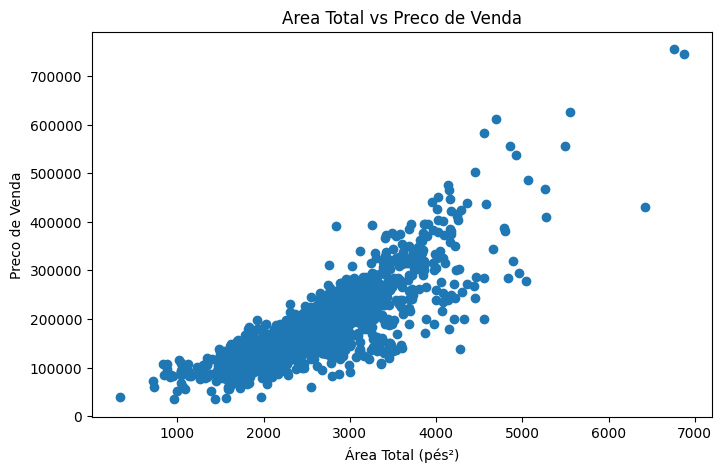

In [315]:
plt.figure(figsize=(8, 5))
plt.scatter(train_df["Area_Total_Construida"], train_df["Preco_Venda"])
plt.xlabel("Área Total (pés²)")
plt.ylabel("Preco de Venda")
plt.title("Area Total vs Preco de Venda")
plt.show()

**Análise do Gráfico de Dispersão:**

A partir da visualização inicial dos dados, é possível observar uma clara tendência linear positiva entre as duas variáveis: de modo geral, quanto maior a área construída da casa (em pés²), maior tende a ser o seu valor de venda, o que fundamenta a escolha deste modelo.

In [316]:
X_train_simples = X.loc[X_train.index, ["Area_Total_Construida"]]
X_test_simples = X.loc[X_test.index, ["Area_Total_Construida"]]

modelo = LinearRegression()
modelo.fit(X_train_simples, y_train)

print("Intercepto:", modelo.intercept_)
print("Coeficiente angular:", modelo.coef_[0])

Intercepto: -42521.10269660724
Coeficiente angular: 87.3397039075974


**Entendendo os valores**

**Intercepto (\$ -42.521,10):** Na teoria, seria o preço de uma casa com 0 pé² de área. Mas como nenhuma casa de verdade tem área zero, esse número **não deve ser levado ao pé da letra**. Ele é só o ponto onde a reta cruza o eixo Y, resultado de esticar a tendência para bem longe da faixa real das casas (que vão de 330 a 6.900 pés²).

**Coeficiente (\$ 87,34):** O coeficiente define a inclinação da reta de regressão e, nesta escala, possui uma leitura direta e intuitiva: para **cada pé quadrado adicional** de área construída, o modelo prevê um acréscimo de aproximadamente **\$ 87,34** no valor de venda da casa.

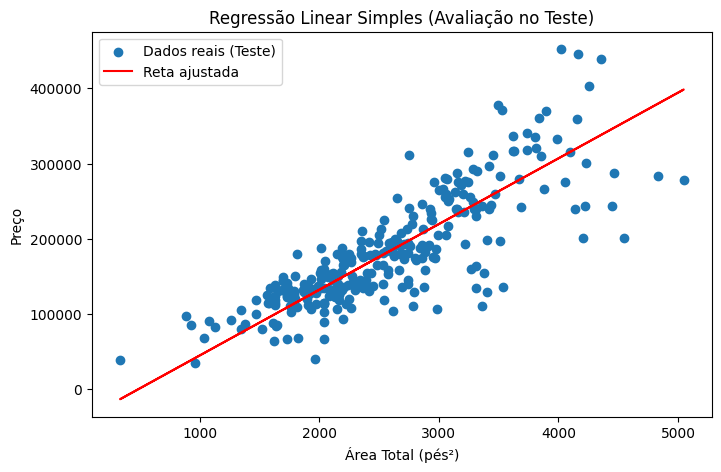

In [317]:
y_pred = modelo.predict(X_test_simples)

plt.figure(figsize=(8, 5))
plt.scatter(X_test_simples["Area_Total_Construida"], y_test, label="Dados reais (Teste)")
plt.plot(X_test_simples["Area_Total_Construida"], y_pred, color="red", label="Reta ajustada")
plt.xlabel("Área Total (pés²)")
plt.ylabel("Preço")
plt.title("Regressão Linear Simples (Avaliação no Teste)")
plt.legend()
plt.show()

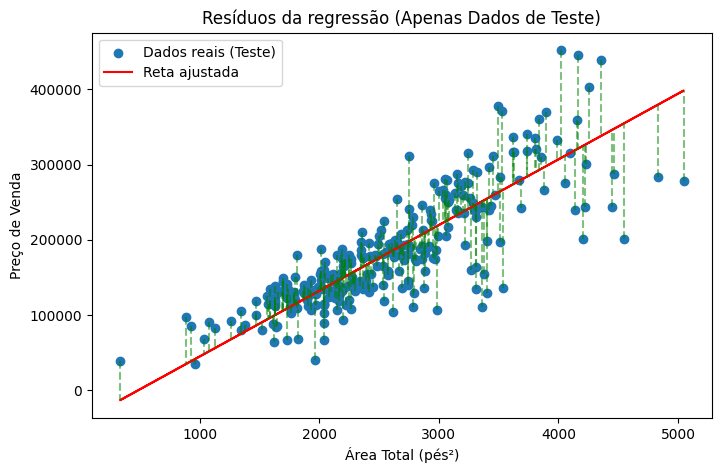

In [318]:
residuos = y_test - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(X_test_simples["Area_Total_Construida"], y_test, label="Dados reais (Teste)")
plt.plot(X_test_simples["Area_Total_Construida"], y_pred, color="red", label="Reta ajustada")

for i in range(len(X_test_simples)):
    plt.plot(
        [X_test_simples["Area_Total_Construida"].iloc[i], X_test_simples["Area_Total_Construida"].iloc[i]],
        [y_test.iloc[i], y_pred[i]],
        linestyle="--", color="green", alpha=0.5
    )

plt.xlabel("Área Total (pés²)")
plt.ylabel("Preço de Venda")
plt.title("Resíduos da regressão (Apenas Dados de Teste)")

plt.legend()
plt.show()

**Resíduos:**

No gráfico acima, adicionamos uma nova camada de informação: as linhas verdes tracejadas (Resíduos). De forma simples, as linhas tracejadas mostram a distância entre valor observado e valor previsto.

* **O Ponto Azul**: É a realidade. Representa o preço real pelo qual a casa foi vendida.
* **A Reta Vermelha**: É a previsão. Representa o preço que o nosso modelo estimou com base no tamanho da casa.
* **A Linha Verde**: É a distância entre os dois. Quanto mais longa for essa linha, maior foi o erro do modelo em dólares para aquele imóvel específico. Se o ponto azul estiver exatamente em cima da reta vermelha, significa que o modelo cravou o preço.

Analisar os resíduos visualmente é essencial para atestar a qualidade da Regressão Linear. O nosso objetivo não é ter zero erros, mas sim garantir que essas linhas verdes sejam as mais curtas possíveis e que estejam distribuídas de forma equilibrada. 

In [319]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"Coeficiente de Determinação (R²): {r2:.4f}")
print(f"Erro Absoluto Médio (MAE): $ {mae:.2f}")

Coeficiente de Determinação (R²): 0.6652
Erro Absoluto Médio (MAE): $ 31623.13


**Avaliação do Modelo**

Para provar a eficiência matemática do nosso modelo de Regressão Linear Simples, calculamos duas métricas principais.
* **O Coeficiente de Determinação**: (R² = 66,52%)
O R² funciona como uma "nota" de desempenho comparada a um palpite cego na média de preços. Alcançar o valor de **66,52%** é um resultado excelente para um modelo de regressão simples (que usa apenas um eixo X). Esse sucesso é mérito da nossa preparação dos dados: ao invés de passar uma área isolada, entregamos ao algoritmo uma "super variável" que representa o tamanho real e completo do imóvel. Isso permitiu que o modelo explicasse sozinho mais da metade de toda a variação dos preços! Os 33% restantes apenas evidenciam que características de naturezas diferentes (como localização ou qualidade do acabamento) ainda exercem influência no valor final.

* **O Erro Absoluto Médio:** (MAE = \$ 31.623,13)
Enquanto o R² nos dá uma porcentagem geral, o MAE traduz o nosso erro de volta para o mundo real, em dólares. Essa métrica indica que, em média, as previsões do nosso modelo erram o valor real de venda em cerca de **\$ 31.623** (para mais ou para menos). Considerando as altas cifras do mercado imobiliário e o fato de estarmos baseando a predição em uma única variável consolidada, é uma margem de erro bastante sólida e realista.

## 3.2 Classificação

In [320]:
mediana_preco = y_train.median()
y_train_binario = (y_train > mediana_preco).astype(int)
y_test_binario = (y_test > mediana_preco).astype(int)

modelo_classificacao = GaussianNB()
modelo_classificacao.fit(X_train_simples, y_train_binario)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[583.,583.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.5,0.5]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](2,)","[0,1]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,0.0005971
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Area_Total_Construida']
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 1)","[[2069.15], [3045.24]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 1)","[[253186.28], [464696.32]]"


**Classificação**

Nesta etapa, mudamos a nossa abordagem de análise. Em vez de prever o valor exato em dólares (Regressão), o nosso objetivo agora é classificar os imóveis em duas categorias distintas: **Preço Baixo (0)** e **Preço Alto (1)**.

Para fazer isso de forma equilibrada, utilizamos a **mediana** dos preços reais como a nossa linha de corte. Garantindo que a nossa base fique perfeitamente dividida ao meio (50% de casas baratas e 50% de casas caras), evitando que o algoritmo fique "viciado" em uma categoria que apareça com mais frequência.

**O Algoritmo: Naive Bayes**
O modelo escolhido para essa tarefa foi o `GaussianNB` (Naive Bayes). O seu grande diferencial é que ele não entrega apenas uma resposta engessada (0 ou 1). Ele calcula a **probabilidade** daquela resposta ser verdadeira. 

In [321]:
entrada_teste = X_test_simples.head(10)
probs = modelo_classificacao.predict_proba(entrada_teste)

resultado = pd.DataFrame(probs, columns=["Preço Baixo (0)", "Preço Alto (1)"])
resultado.index = [f"Casa (Índice Original: {i})" for i in entrada_teste.index]

display((resultado * 100).round(2).astype(str) + "%")

,Preço Baixo (0),Preço Alto (1)
Casa (Índice Original: 1322),43.36%,56.64%
Casa (Índice Original: 837),90.59%,9.41%
Casa (Índice Original: 413),80.18%,19.82%
Casa (Índice Original: 522),43.75%,56.25%
Casa (Índice Original: 1036),8.61%,91.39%
Casa (Índice Original: 615),81.6%,18.4%
Casa (Índice Original: 218),37.18%,62.82%
Casa (Índice Original: 1032),0.49%,99.51%
Casa (Índice Original: 1289),16.58%,83.42%
Casa (Índice Original: 887),73.45%,26.55%


Na tabela acima, testamos o modelo com as primeiras casas da nossa base para entender como está funcionando.

Ex: Certeza Absoluta (Ex: Casa de Índice 1032): O modelo aponta 99,51% de chance dessa casa ser da categoria Preço Alto. Provavelmente, ela possui uma área construída tão grande que não deixou espaço para dúvidas. Em Cima do Muro (Ex: Casa de Índice 522): O modelo ficou praticamente dividido, dando cerca de 56% de chance para Preço Alto e 44% para Preço Baixo. Isso nos mostra que essa casa específica tem um tamanho muito "médio", tornando a decisão de preço um verdadeiro cara-ou-coroa apenas olhando para a área.


Acurácia no Conjunto de Teste: 82.19%



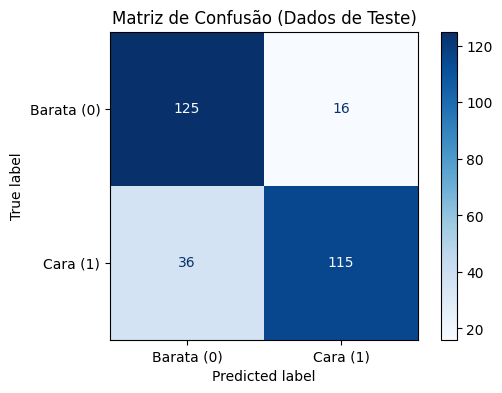

In [322]:
y_pred_test = modelo_classificacao.predict(X_test_simples)

acuracia = accuracy_score(y_test_binario, y_pred_test)
print(f"Acurácia no Conjunto de Teste: {acuracia * 100:.2f}%\n")

matriz = confusion_matrix(y_test_binario, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=matriz, display_labels=["Barata (0)", "Cara (1)"])

fig, ax = plt.subplots(figsize=(6, 4))
disp.plot(cmap="Blues", values_format="d", ax=ax)
plt.title("Matriz de Confusão (Dados de Teste)")
plt.show()

**Avaliação do Modelo**

Após entendermos como o modelo pensa através das probabilidades, precisamos avaliar o "boletim de desempenho" final da nossa inteligência artificial. Para isso, utilizamos a Acurácia e a Matriz de Confusão.

* **Acurácia (82,19%):** É a nossa taxa geral de acerto. De todas as casas testadas, o modelo conseguiu adivinhar a categoria correta em cerca de 82% das vezes utilizando apenas o tamanho da Área Total. Um desempenho bastante sólido considerando que estamos usando apenas uma única variável!

* **Lendo a Matriz de Confusão:** Enquanto a acurácia nos dá a nota geral, a Matriz de Confusão funciona como um "raio-x" visual que nos mostra exatamente onde o modelo acertou e onde ele escorregou:

* **Os Acertos (Quadrados em azul-escuro na diagonal):** O modelo classificou corretamente 125 casas como Baratas e 115 casas como Caras.
  - Os Alarmes Falsos (16 casas): O modelo analisou a área, achou que eram **Caras**, mas na verdade eram **Baratas**.
  - Os Tesouros Escondidos / Falsos Negativos (36 casas): O modelo olhou o tamanho e achou que eram **Baratas**, mas na realidade eram **Caras**.

# 4. Aprendizagem Não Supervisionada

### Nota Técnica: A Interpretação dos Eixos Normalizados (-5, 0, 5)

Ao observar alguns dos gráficos de dispersão, é possível notar que os eixos X apresentam escalas com valores negativos e próximos a zero (ex: -5, 0, 5), em vez das medidas originais em pés quadrados.

Isso é um reflexo visual da **Padronização dos Dados**, uma etapa obrigatória antes de aplicar os algoritmos baseados em distância como o K-Means e o LOF.

Na prática, **O Ponto Zero (0)** representa a média exata daquela característica em todo o conjunto de dados.  
Quanto aos **Valores Positivos e Negativos**, os números representam o *Desvio Padrão* em relação à média. Portanto, um valor sendo -2 no eixo de Área indica uma casa consideravelmente menor que a média da cidade, enquanto um valor de +5 indica uma propriedade com dimensões muito superiores ao padrão local.

## 4.1 Redução de Dimensionalidade (PCA)

In [323]:
colunas_para_cluster = [
    'Area_Total_Construida', 
    'Area_Habitavel_Acima_Solo', 
    'Total_Banheiros', 
    'Capacidade_Carros_Garagem',
    'Qualidade_Geral',
    'Idade_Imovel_Venda',
    'Idade_Reforma_Venda'
]

colunas_reais = [col for col in colunas_para_cluster if col in X.columns]
X_cluster = X[colunas_reais].copy()

scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

pca = PCA(n_components=0.90, random_state=42)
X_pca = pca.fit_transform(X_cluster_scaled)

print(f"Número de componentes retidos pelo PCA para uso no K-Means: {X_pca.shape[1]}")

Número de componentes retidos pelo PCA para uso no K-Means: 5


**Por que utilizamos a Redução de Dimensionalidade (PCA) antes da clusterização?**
Originalmente, tínhamos dezenas de características estruturais e variáveis categóricas que geram "ruído" matemático em algoritmos de distância. Aplicamos o PCA logo no início para atuar como um compressor. Ele calcula as direções de maior variância dos dados, filtrando as informações menos relevantes e transformando as principais características numéricas num espaço comprimido e otimizado. Isso não só facilita a visualização em gráficos 2D, mas melhora drasticamente a qualidade matemática dos clusters que serão criados a seguir.

## 4.2 Clusterização
### 4.2.1 Implementação do Método do Cotovelo

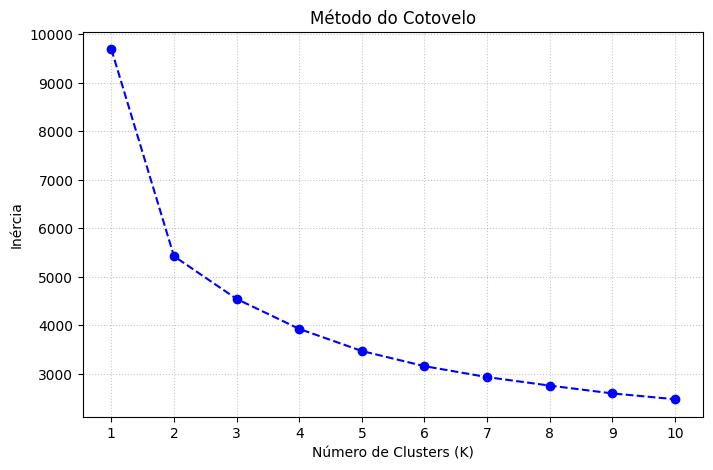

In [324]:
inercia = []
valores_k = range(1, 11)

for k in valores_k:
    kmeans_teste = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_teste.fit(X_pca)
    inercia.append(kmeans_teste.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(valores_k, inercia, marker='o', linestyle='--', color='b')
plt.title('Método do Cotovelo')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inércia')
plt.xticks(valores_k)
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

**Qual a utilidade do método do Cotovelo para definição dos Clusters?**
O Método do Cotovelo é utilizado para nos permitir encontrar a quantidade ideal de grupos, identificando o ponto exato onde o ganho em reduzir a variância (inércia) passa a ser insignificante, evitando a criação de grupos desnecessários. Diante disso, optamos por executar o método previamente ao treinamento do modelo, avaliando o espaço já comprimido pelo PCA.

### 4.2.2 Algoritmo de Clusterização: K-Means

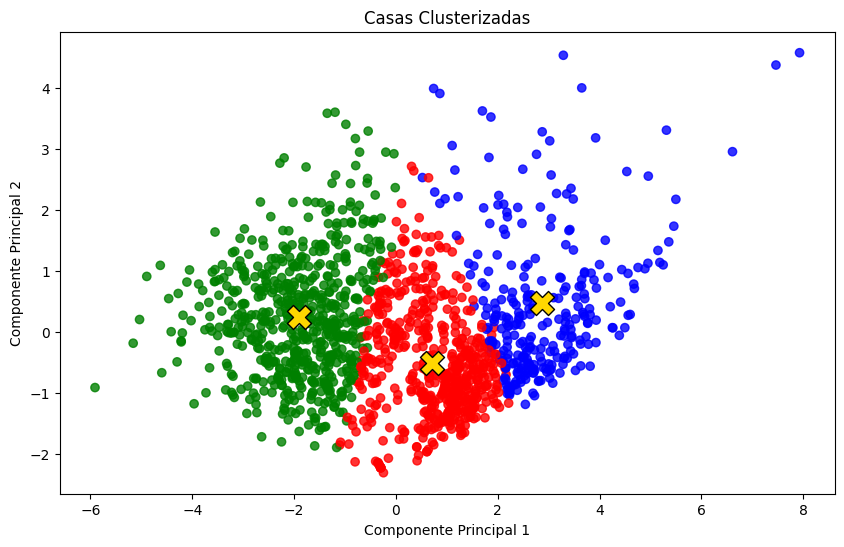

In [325]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_clusters = kmeans.fit_predict(X_pca)
train_df['cluster'] = labels_clusters

cores = {0: 'red', 1: 'blue', 2: 'green'}
train_df['color'] = train_df['cluster'].map(cores)

plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], color=train_df['color'], alpha=0.8)

centroides = kmeans.cluster_centers_
plt.scatter(centroides[:, 0], centroides[:, 1], marker='X', s=300, color='gold', edgecolor='black')

plt.title('Casas Clusterizadas')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.show()

**Por que escolhemos o K-Means?**
No mercado imobiliário, os imóveis não se distribuem de forma totalmente caótica; eles se organizam naturalmente em nichos de consumo. Escolhemos o K-Means porque ele possui excelente performance para processar e cruzar múltiplas características estruturais simultaneamente.

**A remoção da variável alvo ('Preco_Venda')**
A coluna 'Preco_Venda' foi intencionalmente removida para que o conjunto de dados de treinamento não fosse totalmente dominado pela sua magnitude, fazendo com que a IA criasse grupos baseados puramente em faixas de preço. Portanto, o modelo considera características físicas das casas, o que altera a forma como ele organiza os clusters.

### 4.2.3 Perfilagem dos Clusters

In [326]:
colunas_perfil = ['GrLivArea', 'OverallQual', 'GarageCars', 'YearBuilt', 'SalePrice']
df_perfil = train_csv.loc[train_df.index, colunas_perfil].copy()
df_perfil['Cluster'] = train_df['cluster']

resumo_clusters = df_perfil.groupby('Cluster').mean().round(0)

resumo_clusters = resumo_clusters.rename(columns={
    'GrLivArea': 'Média de Área (Pés²)',
    'OverallQual': 'Qualidade Média (1-10)',
    'GarageCars': 'Média de Vagas Garagem',
    'YearBuilt': 'Ano Médio de Construção',
    'SalePrice': 'Preço Médio de Venda ($)'
})

display(resumo_clusters)

,Média de Área (Pés²),Qualidade Média (1-10),Média de Vagas Garagem,Ano Médio de Construção,Preço Médio de Venda ($)
Cluster,,,,,
0,1513.0,6.0,2.0,1988.0,184787.0
1,2178.0,8.0,3.0,1993.0,298536.0
2,1209.0,5.0,1.0,1947.0,124761.0


### 4.3 Regras de Associação (Apriori)

In [327]:
df_casas = pd.DataFrame()

df_casas['Ar_Condicionado'] = train_csv['CentralAir'] == 'Y'
df_casas['Lareira'] = train_csv['Fireplaces'] > 0
df_casas['Garagem_dupla_ou_mais'] = train_csv['GarageCars'] >= 2
df_casas['Alta_Qualidade_Geral'] = train_csv['OverallQual'] >=7
df_casas['Porao'] = train_csv['TotalBsmtSF'] > 0
df_casas['Casa_recente_pos_2000'] = train_csv['YearBuilt'] >= 2000

itens_frequentes = apriori(df_casas, min_support=0.3, use_colnames=True)

regras = association_rules(itens_frequentes, metric="confidence", min_threshold=0.7)
regras = regras.sort_values(by='lift', ascending=False)

regras_pt = regras.rename(columns={
    'antecedents': 'Se (Antecedente)',
    'consequents': 'Então (Consequente)',
    'support': 'Suporte (Frequência %)',
    'confidence': 'Confiança (Probabilidade %)',
    'lift': 'Lift (Força da Regra)'
})

colunas_exibir = ['Se (Antecedente)', 'Então (Consequente)', 'Suporte (Frequência %)', 'Confiança (Probabilidade %)', 'Lift (Força da Regra)']

display(regras_pt[colunas_exibir].head(10))

,Se (Antecedente),Então (Consequente),Suporte (Frequência %),Confiança (Probabilidade %),Lift (Força da Regra)
47,frozenset({Alta_Qualidade_Geral}),"frozenset({Ar_Condicionado, Garagem_dupla_ou_m...",0.356164,0.948905,1.438631
44,"frozenset({Alta_Qualidade_Geral, Ar_Condiciona...","frozenset({Garagem_dupla_ou_mais, Porao})",0.356164,0.959410,1.417751
19,frozenset({Alta_Qualidade_Geral}),"frozenset({Ar_Condicionado, Garagem_dupla_ou_m...",0.356849,0.950730,1.416394
46,"frozenset({Alta_Qualidade_Geral, Porao})","frozenset({Ar_Condicionado, Garagem_dupla_ou_m...",0.356164,0.950640,1.416259
33,frozenset({Alta_Qualidade_Geral}),"frozenset({Garagem_dupla_ou_mais, Porao})",0.358904,0.956204,1.413015
17,"frozenset({Alta_Qualidade_Geral, Ar_Condiciona...",frozenset({Garagem_dupla_ou_mais}),0.356849,0.961255,1.389536
42,"frozenset({Alta_Qualidade_Geral, Ar_Condiciona...",frozenset({Garagem_dupla_ou_mais}),0.356164,0.961183,1.389433
8,frozenset({Alta_Qualidade_Geral}),frozenset({Garagem_dupla_ou_mais}),0.359589,0.958029,1.384874
32,"frozenset({Alta_Qualidade_Geral, Porao})",frozenset({Garagem_dupla_ou_mais}),0.358904,0.957952,1.384763
40,frozenset({Lareira}),"frozenset({Ar_Condicionado, Garagem_dupla_ou_m...",0.423288,0.802597,1.216814


**Por que utilizamos o Apriori?**
  
O algoritmo Apriori permite a descoberta de regras de associação, ou seja, ele nos permite validar regras de associação entre as variáveis usadas pelo modelo.

O **Suporte (Frequência)** apresenta a frequência de ocorrência desses casos em cima dos dados gerais.  
A **Confiança (Probabilidade)** apresenta a probabilidade de a regra ocorrer.  
E, por fim, o **Lift**, que representa a força da regra, provando a não mera coincidência, considerando que isso se aplica a lifts maiores que 1.0.

## 4.4 Local Outlier Factor

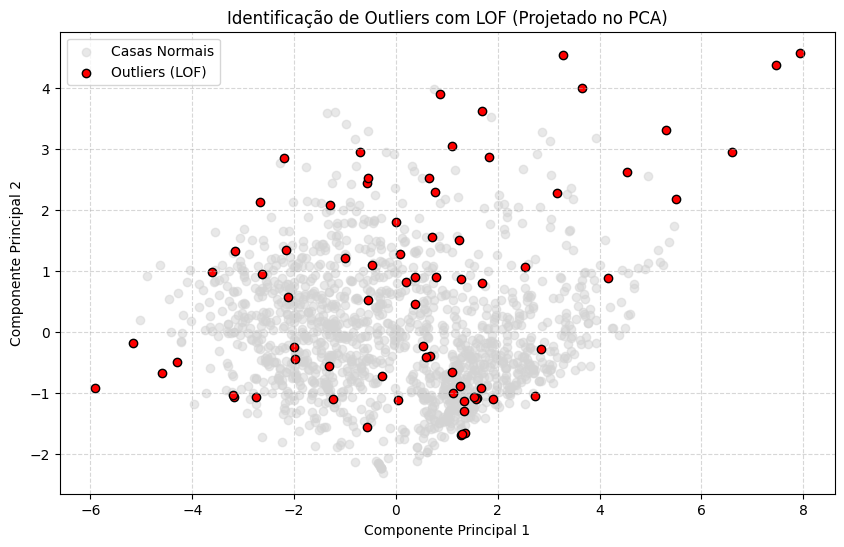

In [328]:
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
previsoes_outliers = lof.fit_predict(X_pca)
train_df['Outlier'] = previsoes_outliers

plt.figure(figsize=(10, 6))

# Visualização dos pontos
inliers_idx = previsoes_outliers == 1
plt.scatter(X_pca[inliers_idx, 0], X_pca[inliers_idx, 1], color='lightgray', alpha=0.5, label='Casas Normais')

outliers_idx = previsoes_outliers == -1
plt.scatter(X_pca[outliers_idx, 0], X_pca[outliers_idx, 1], color='red', edgecolor='black', label='Outliers (LOF)')

plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('Identificação de Outliers com LOF (Projetado no PCA)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**Por que utilizamos o Local Outlier Factor (LOF)?**

O LOF é um modelo de detecção de anomalias baseado em densidade. Basicamente, ele mede a distância de uma casa para os seus 20 vizinhos estruturais mais próximos. Se a casa estiver muito mais isolada do que a média dos seus vizinhos, ela é classificada como uma anomalia (-1).  

Na prática, esse modelo nos permite visualizar casas que possuem configurações raras, ou seja, destoantes das demais casas que estão na cor cinza.

## 5. Métricas de avaliação e comparação

### 5.1 Avaliação do modelo supervisionado — Regressão Linear

In [329]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Previsão no conjunto de teste
y_pred_regressao = modelo.predict(X_test_simples)

# Valores reais do teste
y_real_regressao = y_test

# Métricas da regressão
r2 = r2_score(y_real_regressao, y_pred_regressao)
mae = mean_absolute_error(y_real_regressao, y_pred_regressao)
mse = mean_squared_error(y_real_regressao, y_pred_regressao)
rmse = np.sqrt(mse)

metricas_regressao = pd.DataFrame({
    "Métrica": ["R²", "MAE", "MSE", "RMSE"],
    "Resultado": [r2, mae, mse, rmse]
})

metricas_regressao

,Métrica,Resultado
0,R²,6.652203e-01
1,MAE,3.162313e+04
2,MSE,1.849232e+09
3,RMSE,4.300269e+04


### Análise dos resultados da Regressão Linear

Os resultados mostram que o modelo de **Regressão Linear** conseguiu prever parte dos preços das casas com base nos dados de teste.

O **R²** foi de **0,6552**, indicando que o modelo consegue explicar aproximadamente **65,5% da variação dos preços das casas**. Isso mostra um desempenho razoável.

O **MAE** foi de **31.623,13**, o que significa que, em média, o modelo erra o preço das casas em cerca de **R$ 31 mil**.

O **MSE** foi de **1.849.232.000**. Esse valor é alto porque essa métrica eleva os erros ao quadrado, dando mais peso para erros maiores.

O **RMSE** foi de **43.002,69**, indicando que o erro médio do modelo é de aproximadamente **R$ 43 mil**.

Dessa forma, o desempenho da Regressão Linear pode ser considerado **razoável**, pois o modelo conseguiu identificar uma relação entre os dados utilizados e o preço das casas, mas ainda apresenta erros consideráveis nas previsões.


# 5.2 Avaliação do Modelo Não Supervisionado

Nesta etapa, foi avaliado o desempenho do modelo não supervisionado **K-Means**.

O K-Means já havia sido treinado anteriormente no notebook, então não foi necessário treinar o modelo novamente. Agora, foram utilizadas métricas específicas para verificar se os grupos formados pelo modelo ficaram bem organizados.

Como o K-Means não prevê um valor real, como acontece na Regressão Linear, sua avaliação é feita analisando a qualidade dos agrupamentos criados.

As métricas utilizadas foram:

* **Silhouette Score:** mostra se os dados ficaram bem agrupados e separados dos outros grupos.
* **Davies-Bouldin Index:** mede a separação entre os grupos. Quanto menor o valor, melhor.
* **Calinski-Harabasz Index:** avalia se os grupos estão bem separados e organizados. Quanto maior o valor, melhor.

Dessa forma, essa etapa permite verificar se o K-Means conseguiu formar grupos coerentes de imóveis com características semelhantes.


In [330]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

silhouette = silhouette_score(X_pca, labels_clusters)
davies_bouldin = davies_bouldin_score(X_pca, labels_clusters)
calinski = calinski_harabasz_score(X_pca, labels_clusters)

metricas_kmeans = pd.DataFrame({
    "Métrica": ["Silhouette Score", "Davies-Bouldin Index", "Calinski-Harabasz Index"],
    "Resultado": [silhouette, davies_bouldin, calinski]
})

display(metricas_kmeans)

,Métrica,Resultado
0,Silhouette Score,0.270623
1,Davies-Bouldin Index,1.240914
2,Calinski-Harabasz Index,823.492978


### Análise dos resultados do K-Means

Os resultados mostram que o modelo **K-Means** conseguiu formar grupos de imóveis com características semelhantes.

O **Silhouette Score** foi de **0,27**, indicando que os grupos existem, mas ainda possuem certa sobreposição. Isso significa que alguns imóveis podem ter características parecidas com mais de um grupo.

O **Davies-Bouldin Index** foi de **1,24**. Como valores menores são melhores, esse resultado mostra uma separação razoável entre os clusters.

O **Calinski-Harabasz Index** foi de **823,49**, indicando que existe uma boa organização geral dos grupos.

Dessa forma, o desempenho do K-Means pode ser considerado **razoável a bom**, pois conseguiu identificar padrões entre os imóveis, mesmo que os grupos não estejam perfeitamente separados.


# 5.3 Comparação entre os modelos


In [331]:
comparacao_modelos = pd.DataFrame({
    "Modelo": ["Regressão Linear", "K-Means"],
    "Tipo": ["Supervisionado", "Não supervisionado"],
    "Objetivo": [
        "Prever o preço das casas",
        "Agrupar casas com características semelhantes"
    ],
    "Principais métricas": [
        "R², MAE, MSE e RMSE",
        "Silhouette, Davies-Bouldin e Calinski-Harabasz"
    ],
    "Resultado geral": [
        "Desempenho razoável na previsão dos preços",
        "Desempenho razoável a bom na formação dos grupos"
    ]
})

comparacao_modelos

,Modelo,Tipo,Objetivo,Principais métricas,Resultado geral
0,Regressão Linear,Supervisionado,Prever o preço das casas,"R², MAE, MSE e RMSE",Desempenho razoável na previsão dos preços
1,K-Means,Não supervisionado,Agrupar casas com características semelhantes,"Silhouette, Davies-Bouldin e Calinski-Harabasz",Desempenho razoável a bom na formação dos grupos


### 5.3 Comparação entre os modelos

A Regressão Linear e o K-Means foram utilizados com objetivos diferentes.

A *Regressão Linear* é um modelo supervisionado e foi usada para prever o preço das casas. Sua avaliação foi feita comparando os valores reais com os valores previstos pelo modelo.

Já o *K-Means* é um modelo não supervisionado e foi usado para agrupar casas com características semelhantes. Nesse caso, o objetivo não foi prever o preço exato, mas identificar padrões dentro da base de dados.

Os resultados da Regressão Linear mostraram um desempenho razoável, pois o modelo conseguiu explicar cerca de 65,5% da variação dos preços, mas ainda apresentou erros consideráveis.

Os resultados do K-Means também foram coerentes, pois o modelo conseguiu formar grupos de imóveis, mesmo que eles não estejam perfeitamente separados.

Dessa forma, os modelos não devem ser comparados diretamente pelas métricas, pois cada um possui uma finalidade diferente. A Regressão Linear é mais adequada para previsão de preços, enquanto o K-Means é útil para identificar grupos e padrões entre os imóveis.